In [16]:
import pandas as pd

# Replace with your file path
file_path = "prosjekt.xlsx"

df = pd.read_excel(file_path)

df.head()


,Calculated Volume (m^3),Actual Volume,C/A Ratio,Gross Rock Volume (m^3),Pore Volume (m^3),Anomaly Map,Area (m^2),Thickness (m),Porosity (%),Hydrocarbon Saturation (%),Net-to-Gross,FVF,Threshold,Zones Applied
0,8304802.5,29000000,0.2864,184551184.0,27682676.0,NRMS_slices_NRMS_A-B,9227559.0,20.0,15.0,30.0,1.0,0.0077,0.5,NaN
1,9688936.0,29000000,0.3341,184551184.0,27682676.0,NRMS_slices_NRMS_A-B,9227559.0,20.0,15.0,35.0,1.0,0.0077,0.5,NaN
2,11073070.0,29000000,0.3818,184551184.0,27682676.0,NRMS_slices_NRMS_A-B,9227559.0,20.0,15.0,40.0,1.0,0.0077,0.5,NaN
3,12457204.0,29000000,0.4296,184551184.0,27682676.0,NRMS_slices_NRMS_A-B,9227559.0,20.0,15.0,45.0,1.0,0.0077,0.5,NaN
4,13841338.0,29000000,0.4773,184551184.0,27682676.0,NRMS_slices_NRMS_A-B,9227559.0,20.0,15.0,50.0,1.0,0.0077,0.5,NaN


In [17]:
df.columns

Index(['Calculated Volume (m^3)', 'Actual Volume', 'C/A Ratio',
       'Gross Rock Volume (m^3)', 'Pore Volume (m^3)', 'Anomaly Map',
       'Area (m^2)', 'Thickness (m)', 'Porosity (%)',
       'Hydrocarbon Saturation (%)', 'Net-to-Gross', 'FVF', 'Threshold',
       'Zones Applied'],
      dtype='str')

In [18]:
import pandas as pd

# Assuming you've already read the Excel file:
# df = pd.read_excel("your_file.xlsx")

# Convert percentage columns to fractions
df["Porosity_frac"] = df["Porosity (%)"] / 100
df["Sat_frac"] = df["Hydrocarbon Saturation (%)"] / 100

# Calculate volume
df["Calculated Volume (m^3)"] = (
    df["Area (m^2)"]
    * df["Sat_frac"]
    * df["Porosity_frac"]
    * df["Net-to-Gross"]
    * df["Thickness (m)"]
) / df["FVF"]


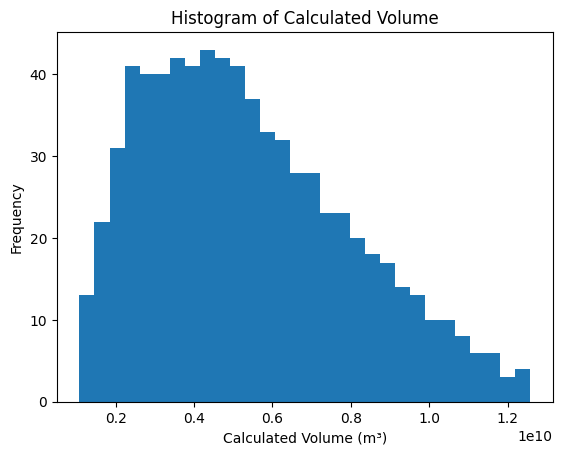

In [19]:
import matplotlib.pyplot as plt

# Drop NaN values just in case
volumes = df["Calculated Volume (m^3)"].dropna()

plt.figure()

plt.hist(volumes, bins=30)

plt.xlabel("Calculated Volume (m³)")
plt.ylabel("Frequency")
plt.title("Histogram of Calculated Volume")

plt.show()

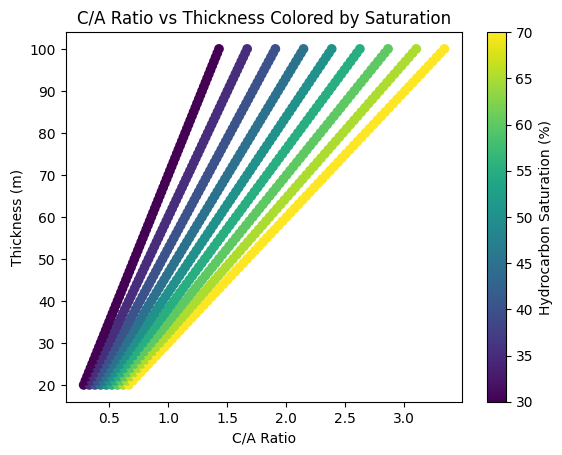

In [20]:
import matplotlib.pyplot as plt

# Remove missing values
plot_df = df[[
    "C/A Ratio",
    "Thickness (m)",
    "Hydrocarbon Saturation (%)"
]].dropna()

plt.figure()

sc = plt.scatter(
    plot_df["C/A Ratio"],
    plot_df["Thickness (m)"],
    c=plot_df["Hydrocarbon Saturation (%)"]
)

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label("Hydrocarbon Saturation (%)")

# Labels
plt.xlabel("C/A Ratio")
plt.ylabel("Thickness (m)")
plt.title("C/A Ratio vs Thickness Colored by Saturation")

plt.show()

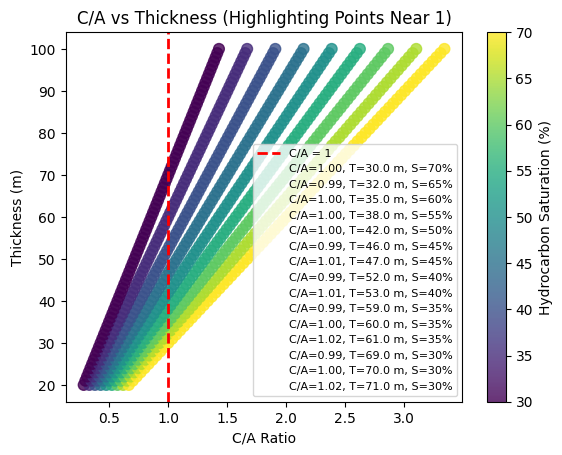

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Columns needed
plot_df = df[[
    "C/A Ratio",
    "Thickness (m)",
    "Hydrocarbon Saturation (%)"
]].dropna()

plt.figure()

# Main scatter
sc = plt.scatter(
    plot_df["C/A Ratio"],
    plot_df["Thickness (m)"],
    c=plot_df["Hydrocarbon Saturation (%)"],
    cmap="viridis",
    s=60,
    alpha=0.8
)

# Vertical red line at x=1
plt.axvline(
    x=1,
    color="red",
    linestyle="--",
    linewidth=2,
    label="C/A = 1"
)

# Select points close to x=1
tolerance = 0.02   # adjust if needed

near_one = plot_df[
    np.abs(plot_df["C/A Ratio"] - 1) < tolerance
]

# Add those points to legend
for i, row in near_one.iterrows():

    label_text = (
        f"C/A={row['C/A Ratio']:.2f}, "
        f"T={row['Thickness (m)']:.1f} m, "
        f"S={row['Hydrocarbon Saturation (%)']:.0f}%"
    )

    plt.scatter(
        row["C/A Ratio"],
        row["Thickness (m)"],
        color="none",
        label=label_text
    )

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label("Hydrocarbon Saturation (%)")

# Labels
plt.xlabel("C/A Ratio")
plt.ylabel("Thickness (m)")
plt.title("C/A vs Thickness (Highlighting Points Near 1)")

plt.legend(fontsize=8)

plt.show()